# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [4]:
se = pd.read_csv("../data/states_edu.csv")
se.head(3)

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [5]:
se.isna().sum()

PRIMARY_KEY                        0
STATE                              0
YEAR                               0
ENROLL                           491
TOTAL_REVENUE                    440
FEDERAL_REVENUE                  440
STATE_REVENUE                    440
LOCAL_REVENUE                    440
TOTAL_EXPENDITURE                440
INSTRUCTION_EXPENDITURE          440
SUPPORT_SERVICES_EXPENDITURE     440
OTHER_EXPENDITURE                491
CAPITAL_OUTLAY_EXPENDITURE       440
GRADES_PK_G                      173
GRADES_KG_G                       83
GRADES_4_G                        83
GRADES_8_G                        83
GRADES_12_G                       83
GRADES_1_8_G                     695
GRADES_9_12_G                    644
GRADES_ALL_G                      83
AVG_MATH_4_SCORE                1150
AVG_MATH_8_SCORE                1113
AVG_READING_4_SCORE             1065
AVG_READING_8_SCORE             1153
dtype: int64

<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: **Grade 4 Math (`AVG_MATH_4_SCORE`)**

How many years of data are logged in our dataset? 

In [21]:
# @@@ 1
# Your Code
years = se["YEAR"].nunique()
print(f"Number of years logged: {years}")
print(f"Year range: {se["YEAR"].min()} - {se["YEAR"].max()}")

Number of years logged: 33
Year range: 1986 - 2019


Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [22]:
# @@@ 2
variable = "AVG_MATH_4_SCORE"

michigan_avg = se.loc[se["STATE"] == "MICHIGAN", variable].mean()
ohio_avg = se.loc[se["STATE"] == "OHIO", variable].mean()

print(f"Michigan average {variable}: {michigan_avg:.2f}")
print(f"Ohio average {variable}: {ohio_avg:.2f}")
print(f"{"Michigan" if michigan_avg > ohio_avg else "Ohio"} has the higher average across all years.")

Michigan average AVG_MATH_4_SCORE: 234.36
Ohio average AVG_MATH_4_SCORE: 239.45
Ohio has the higher average across all years.


Find the average for your chosen test across all states in 2019

In [24]:
# @@@ 3
avg2019 = se.loc[se["YEAR"] == 2019, variable].mean()
print(f"Average {variable} across all states in 2019 is {avg2019:.2f}.")

Average AVG_MATH_4_SCORE across all states in 2019 is 239.94.


For each state, find a maximum value for your chosen test score

In [26]:
# @@@ 4
state_max = se.groupby("STATE")[variable].max()
state_max

STATE
ALABAMA                 233.0
ALASKA                  237.0
ARIZONA                 240.0
ARKANSAS                240.0
CALIFORNIA              235.0
COLORADO                247.0
CONNECTICUT             245.0
DELAWARE                243.0
DISTRICT_OF_COLUMBIA    235.0
DODEA                   250.0
FLORIDA                 246.0
GEORGIA                 240.0
HAWAII                  243.0
IDAHO                   242.0
ILLINOIS                239.0
INDIANA                 249.0
IOWA                    246.0
KANSAS                  248.0
KENTUCKY                242.0
LOUISIANA               234.0
MAINE                   246.0
MARYLAND                247.0
MASSACHUSETTS           253.0
MICHIGAN                238.0
MINNESOTA               253.0
MISSISSIPPI             241.0
MISSOURI                241.0
MONTANA                 244.0
NATIONAL                242.0
NEBRASKA                246.0
NEVADA                  237.0
NEW_HAMPSHIRE           253.0
NEW_JERSEY              249.0
NEW_

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [27]:
# @@@ 5
se_new = se.dropna(subset = [variable]).copy()

se_new['TOTAL_EXPENDITURE_PER_STUDENT'] = se_new['TOTAL_EXPENDITURE'] / se_new['GRADES_4_G']
se_new['INSTRUCTION_PER_STUDENT'] = se_new['INSTRUCTION_EXPENDITURE'] / se_new['GRADES_4_G']
se_new['SUPPORT_PER_STUDENT'] = se_new['SUPPORT_SERVICES_EXPENDITURE'] / se_new['GRADES_4_G']
se_new['FEDERAL_REVENUE_PER_STUDENT'] = se_new['FEDERAL_REVENUE'] / se_new['GRADES_4_G']

features = [
    'YEAR',
    'TOTAL_EXPENDITURE_PER_STUDENT',
    'INSTRUCTION_PER_STUDENT',
    'SUPPORT_PER_STUDENT',
    'FEDERAL_REVENUE_PER_STUDENT',
    'GRADES_4_G',
]

se_new = se_new.dropna(subset=features)
se_new[features + [variable]].describe()

,YEAR,TOTAL_EXPENDITURE_PER_STUDENT,INSTRUCTION_PER_STUDENT,SUPPORT_PER_STUDENT,FEDERAL_REVENUE_PER_STUDENT,GRADES_4_G,AVG_MATH_4_SCORE
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,2006.538636,144.772805,74.844588,43.487994,13.233910,72088.213636,235.550000
std,6.492565,53.124916,29.002723,16.943329,6.132663,84664.993569,9.897297
min,1992.000000,42.470695,23.405051,11.015491,1.987060,4643.000000,192.000000
25%,2003.000000,111.473827,56.441018,32.903766,9.202495,20509.250000,230.000000
50%,2007.000000,139.610176,69.840064,41.277923,12.441253,50528.000000,238.000000
75%,2011.000000,168.512024,88.382202,51.315806,16.558594,80108.500000,243.000000
max,2015.000000,329.609205,209.911941,105.638367,43.462501,493415.000000,253.000000


Feature engineering justification: **I converted absolute dollar figures (total/instruction/support expenditure and federal revenue) into per-student amounts by dividing by `GRADES_4_G`. This removes the confound of state size (California spends more in total than Wyoming simply because it has far more students) and lets the model compare states on a fair, per-pupil basis. I excluded the other test-score columns (8th grade math, 4th/8th grade reading) from the feature set since they are outcomes rather than predictors and would leak information about the response.**

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

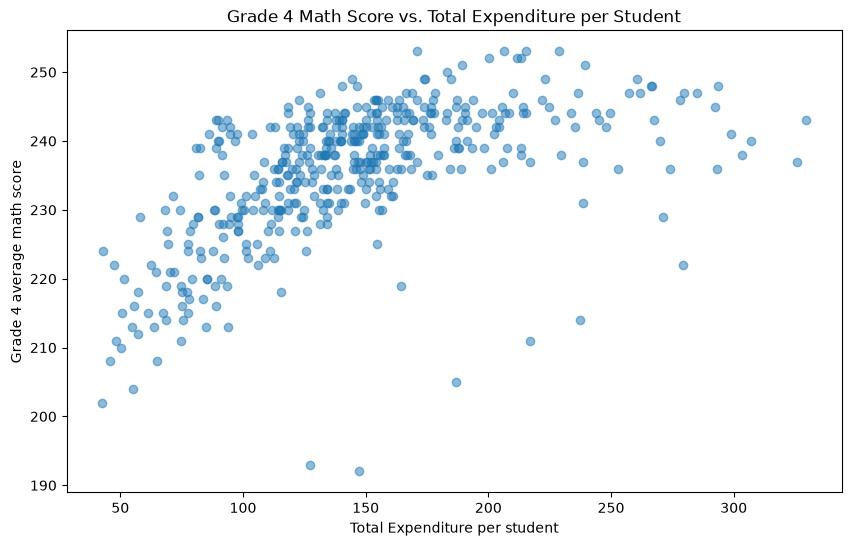

In [28]:
# @@@ 6
plt.figure(figsize = (10,6))
plt.scatter(se_new["TOTAL_EXPENDITURE_PER_STUDENT"], se_new[variable], alpha = 0.5)
plt.xlabel("Total Expenditure per student")
plt.ylabel("Grade 4 average math score")
plt.title("Grade 4 Math Score vs. Total Expenditure per Student")
plt.show()

**There is a mild positive relationship between spending per student and Grade 4 math scores, but the relationship is noisy and far from linear.**

**Visualization 2**

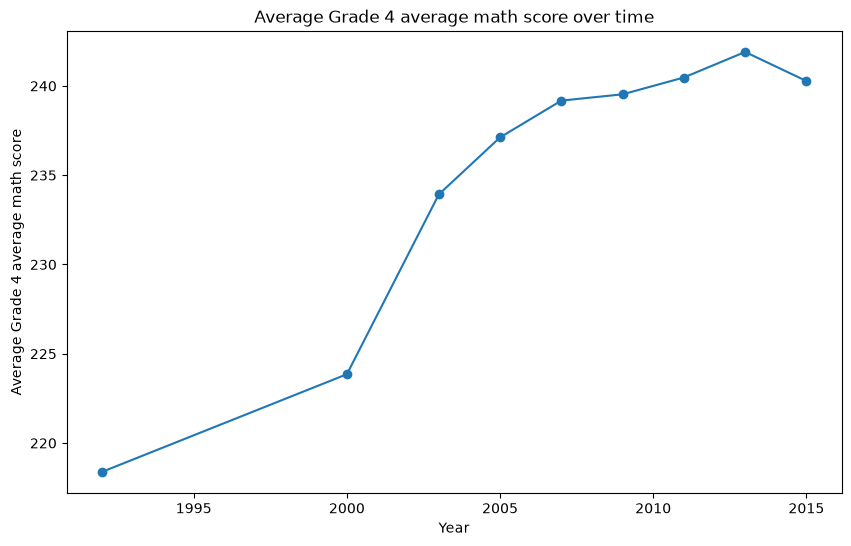

In [30]:
# @@@ 7
year_avg = se_new.groupby("YEAR")[variable].mean()

plt.figure(figsize = (10,6))

plt.plot(year_avg.index, year_avg.values, marker = "o")
plt.xlabel("Year")
plt.ylabel("Average Grade 4 average math score")
plt.title("Average Grade 4 average math score over time")
plt.show()

**National average Grade 4 math scores rose fairly steadily from the early years of the dataset before flattening out in more recent years. This suggests `YEAR` itself carries some predictive signal, separate from spending, and should be included as a feature.**

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
# @@@ 8

X = se_new[features]
y = se_new[variable]

In [33]:
# @@@ 9 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [34]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression

In [35]:
# @@@ 11
# create your model here
model = LinearRegression()

In [36]:
model.fit(X_train, y_train)

UnicodeDecodeError: 'cp950' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp950' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LinearRegression()

In [37]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [38]:
# @@@ 12
from sklearn.metrics import mean_squared_error, r2_score

train_pred = model.predict(X_train)

mse_train = mean_squared_error(y_train, train_pred)
mse_test = mean_squared_error(y_test, y_pred)
r2_train = r2_score(y_train, train_pred)
r2_test = r2_score(y_test, y_pred)

print(f"Training set -> MSE: {mse_train:.3f}, R^2: {r2_train:.3f}")
print(f"Testing set  -> MSE: {mse_test:.3f}, R^2: {r2_test:.3f}")

Training set -> MSE: 36.152, R^2: 0.623
Testing set  -> MSE: 39.075, R^2: 0.613


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

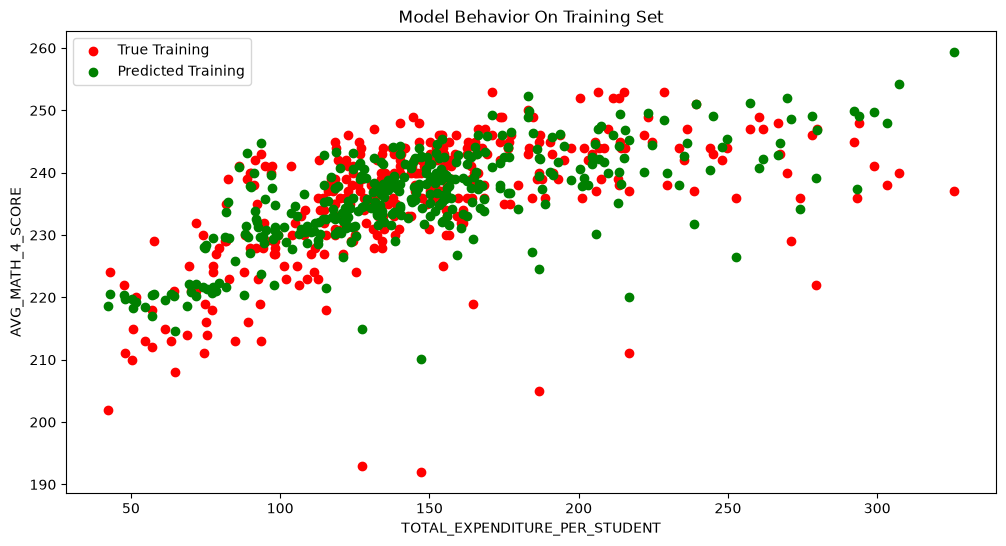

In [40]:
# @@@ 13

col_name = 'TOTAL_EXPENDITURE_PER_STUDENT'


f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel(variable)
plt.title("Model Behavior On Training Set")

Text(0.5, 1.0, 'Model Behavior on Testing Set')

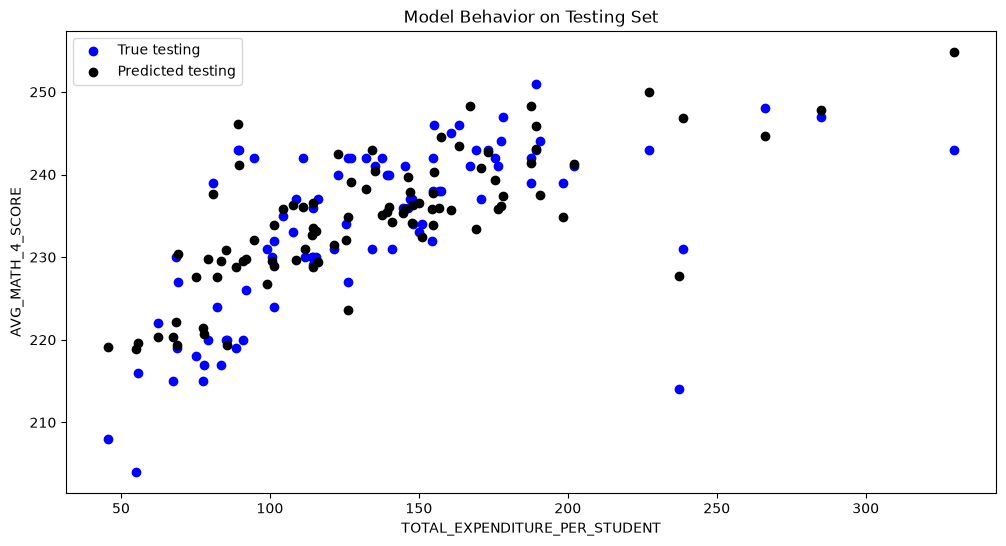

In [41]:
# @@@ 14


col_name = 'TOTAL_EXPENDITURE_PER_STUDENT'


f = plt.figure(figsize=(12,6))
plt.scatter(X_test[col_name], y_test, color = "blue")
plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel(variable)
plt.title("Model Behavior on Testing Set")